In [1]:
import roadrunner
import numpy as np
import matplotlib.pyplot as plt

#1. Load the SBML model
rr = roadrunner.RoadRunner("LipniackiWithCYLD.xml")

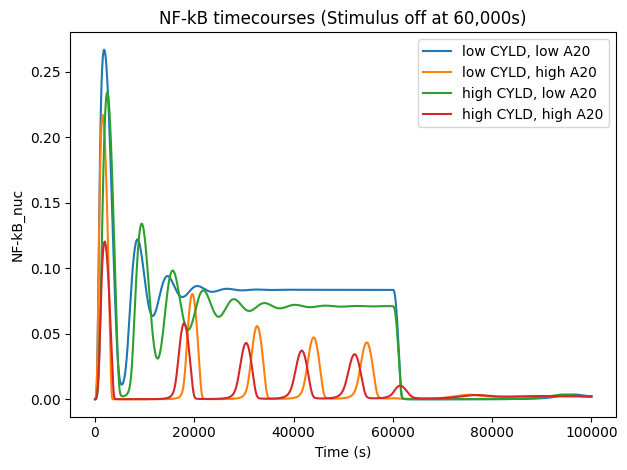

In [2]:
def set_stimulus(on_value = 1.0):
    if "TNF_R" not in rr.model.getGlobalParameterIds():
        raise RuntimeError("The model does not contain the parameter 'TNF_R'.")
    rr["TNF_R"] = float(on_value)

def run_timecourse_tnf_pulse(rr, params, t_off, t_end, n, vars_out):
    rr.resetAll()

    # Set parameters (skip label)
    for k, v in params.items():
        if isinstance(v, (int, float, np.integer, np.floating)):
            rr[k] = float(v) # Ensure the value is a float

    # Time grid
    tgrid = np.linspace(0.0, float(t_end), int(n))
    ioff = int(np.searchsorted(tgrid, float(t_off))) # Index where stimulus is off

    # Clamp so we always have at least 2 points in eah segment
    ioff = max(1, min(ioff, len(tgrid) - 2))

    # TNF on
    set_stimulus(1.0)
    rr.timeCourseSelections = list(vars_out)
    sim_on = rr.simulate(0.0, float(tgrid[ioff]), int(ioff + 1))

    # TNF off
    set_stimulus(0.0)
    sim_off = rr.simulate(float(tgrid[ioff]), float(t_end), int(len(tgrid) - ioff))

    # Stitch (avoid duplicate) junction row)
    sim = np.vstack((sim_on, sim_off[1:]))
    return sim

regimes = [
    {"label":"low CYLD, low A20", "k_cyld":0.1, "k2":0.1},
    {"label":"low CYLD, high A20", "k_cyld":0.1, "k2":10},
    {"label":"high CYLD, low A20", "k_cyld":10, "k2":0.1},
    {"label":"high CYLD, high A20", "k_cyld":10, "k2":10},
]

plt.figure()
for r in regimes:
    m = run_timecourse_tnf_pulse(rr, r, t_off=60000, t_end=100000, n=5001, vars_out=["time", "NFKB_nuc"])
    plt.plot(m[:,0], m[:,1], label=r["label"])

plt.title("NF-kB timecourses (Stimulus off at 60,000s)")
plt.xlabel("Time (s)")
plt.ylabel("NF-kB_nuc")
plt.legend()
plt.tight_layout()
plt.show()

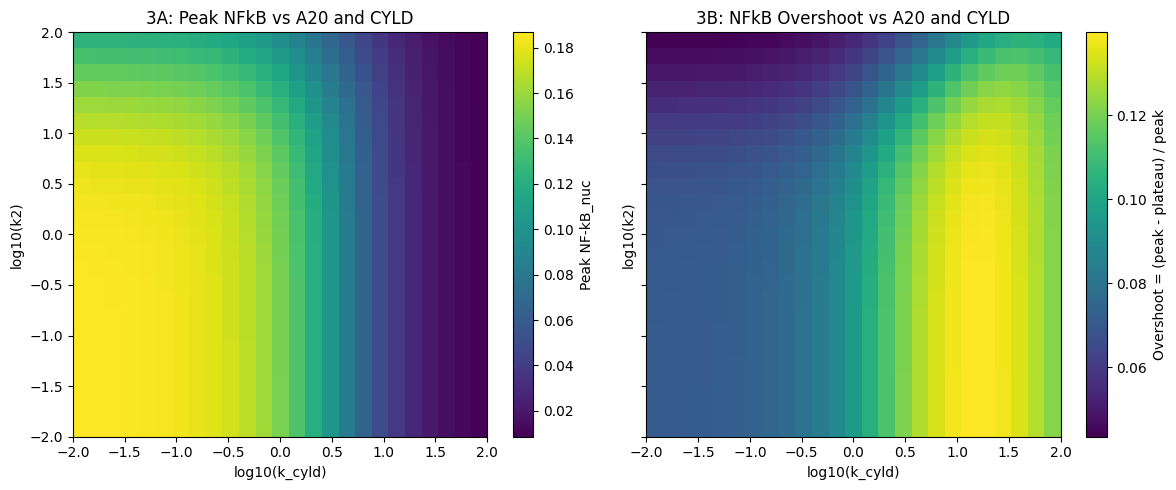

In [3]:
# Figure 3A/3B (single cell): Peak and Overshoot heat maps in log10-parameter space

k2_vals = np.logspace(-2, 2, 25) # Create 25 log-spaced values from 10^-2 to 10^2 for k2 (A20 feedback strength)
kcyld_vals = np.logspace(-2, 2, 25) # Create 25 log-spaced values from 10^-2 to 10^2 for k_cyld (CYLD feedback strength)

peak = np.zeros((len(k2_vals), len(kcyld_vals)))
overshoot = np.zeros_like(peak)

T_END = 1000
NPTS = 5000
PLATEAU_FRAC = 0.10
EPS = 1e-12

for i, k2 in enumerate(k2_vals):
    for j, kc in enumerate(kcyld_vals):
        rr.resetAll()
        set_stimulus(1.0) # Stimulus ALWAYS on for all simulations
        rr["k2"] = float(k2)
        rr["k_cyld"] = float(kc)

        sim = rr.simulate(0, T_END, NPTS, ["time", "NFKB_nuc"])
        y = sim[:, 1]

        pk = float(np.max(y))
        tail = y[int((1 - PLATEAU_FRAC) * len(y)):]
        pl = float(np.mean(tail))

        peak[i, j] = pk
        overshoot[i, j] = (pk - pl) / (pk + EPS)

# Axes displayed as log10(k) values
extent = [
    np.log10(kcyld_vals[0]), np.log10(kcyld_vals[-1]),
    np.log10(k2_vals[0]), np.log10(k2_vals[-1])
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex = True, sharey = True)

im0 = axes[0].imshow(peak, origin='lower', extent=extent, aspect='auto')
plt.colorbar(im0, ax=axes[0], label='Peak NF-kB_nuc')
axes[0].set_title('3A: Peak NFkB vs A20 and CYLD')
axes[0].set_xlabel('log10(k_cyld)')
axes[0].set_ylabel('log10(k2)')

im1 = axes[1].imshow(overshoot, origin='lower', extent=extent, aspect='auto')
plt.colorbar(im1, ax=axes[1], label='Overshoot = (peak - plateau) / peak')
axes[1].set_title('3B: NFkB Overshoot vs A20 and CYLD')
axes[1].set_xlabel('log10(k_cyld)')
axes[1].set_ylabel('log10(k2)')

plt.tight_layout()
plt.show()

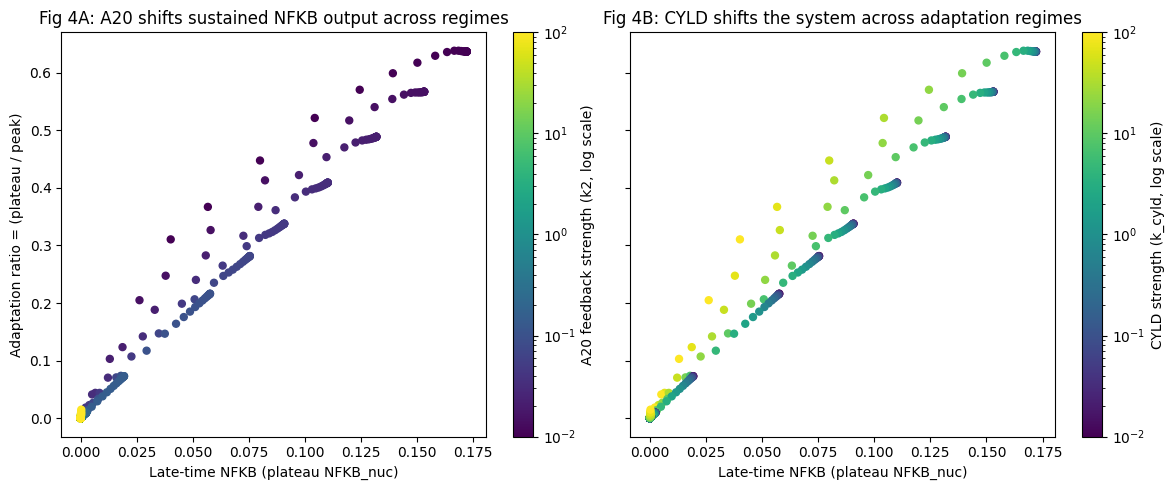

In [4]:
from matplotlib.colors import LogNorm

T_END = 7200    # Longer so "plateu" is actually late-time behavior
NPTS = 4001     # Number of timepoints
PLATEAU_FRAC = 0.10 
EPS = 1e-12

def simulate_step(k2, kcyld):
    rr.resetAll()
    rr["TNF_R"] = 1.0   # Stimulus always on for this figure
    rr["k2"] = float(k2)
    rr["k_cyld"] = float(kcyld)
    sim = rr.simulate(0, T_END, NPTS, ["time", "NFKB_nuc"])
    return sim[:, 0], sim[:, 1]

def plateau_peak_metrics(y):
    peak = float(np.max(y))
    tail = y[int((1 - PLATEAU_FRAC) * len(y)):]
    plateau = float(np.mean(tail))
    adapt = plateau / (peak + EPS)  # How well did NFKB shut itself down (0=perfect adaptation, 1=no adaptation)
    overshoot = 1.0 - adapt  # (peak - plateau) / peak
    return plateau, peak, adapt, overshoot

# Log-spaced parameter grid
k2_vals = np.logspace(-2, 2, 25)
kcyld_vals = np.logspace(-2, 2, 25)

plateaus, adapts, overshoots, k2_pts, kcyld_pts = [], [], [], [], []

for k2 in k2_vals:
    for kc in kcyld_vals:
        _, y = simulate_step(k2, kc)
        p1, pk, ad, ov = plateau_peak_metrics(y)
        plateaus.append(p1)
        adapts.append(ad)
        overshoots.append(ov)
        k2_pts.append(k2)
        kcyld_pts.append(kc)

plateaus = np.array(plateaus)
adapts = np.array(adapts)
overshoots = np.array(overshoots)
k2_pts = np.array(k2_pts)
kcyld_pts = np.array(kcyld_pts)

# Plot: use ADAPTATION on y-axis (cleaner "dynamics" metric than overshoot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# 4A: color by k2
scatter1 = axes[0].scatter(
    plateaus, adapts,
    c=k2_pts, s=25,
    norm=LogNorm(vmin=k2_vals.min(), vmax=k2_vals.max()),
    cmap='viridis'
)

colorBar1 = plt.colorbar(scatter1, ax=axes[0])
colorBar1.set_label("A20 feedback strength (k2, log scale)")
axes[0].set_title("Fig 4A: A20 shifts sustained NFKB output across regimes")
axes[0].set_xlabel("Late-time NFKB (plateau NFKB_nuc)")
axes[0].set_ylabel("Adaptation ratio = (plateau / peak)")

# 4B: color by k_cyld
scatter2 = axes[1].scatter(
    plateaus, adapts,
    c=kcyld_pts, s=25,
    norm=LogNorm(vmin=kcyld_vals.min(), vmax=kcyld_vals.max()),
    cmap='viridis'
)

colorBar2 = plt.colorbar(scatter2, ax=axes[1])
colorBar2.set_label("CYLD strength (k_cyld, log scale)")
axes[1].set_title("Fig 4B: CYLD shifts the system across adaptation regimes")
axes[1].set_xlabel("Late-time NFKB (plateau NFKB_nuc)")

plt.tight_layout()
plt.show()

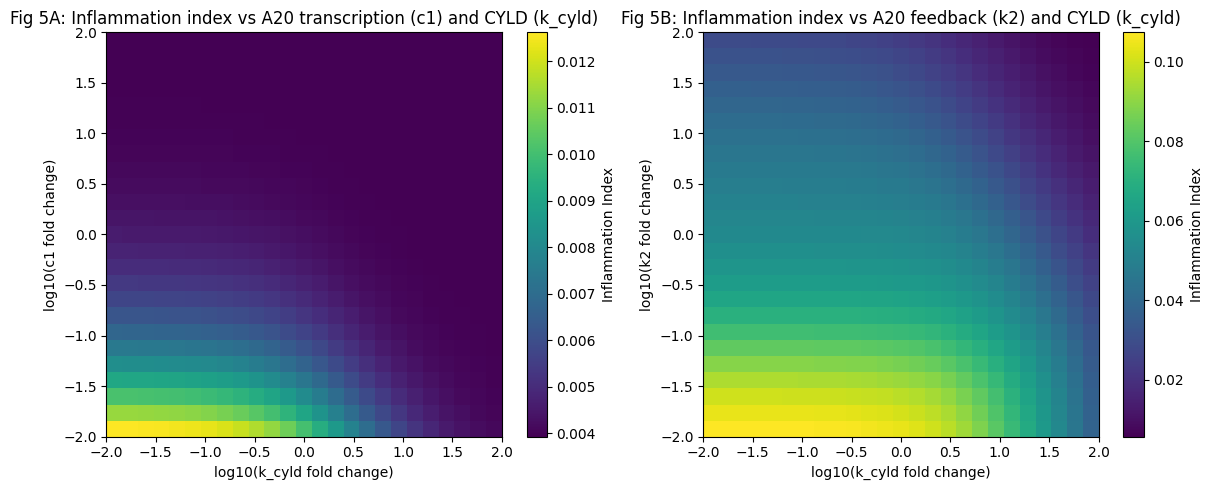

In [5]:
# Figure 5A/ 5B: Inflamation Index
# 5A = (c1, k_cyld) and 5B = (k2, k_cyld)
# Assuming rr, np, and plt already exist (no imports)

# Simulation + metric settings
simulation_end_time_seconds = 6500
num_timepoints = 4001
tnf_pulse_off_time_seconds = 3600
plateau_tail_fraction = 0.10
nfkb_output_species_id = "NFKB_nuc"

# Parameter scan settings
fold_change_min, fold_change_max, num_grid_points = 1e-2, 1e2, 25
a20_transcription_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) # c1
a20_feedback_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) # k2
cyld_fold_grid = np.logspace(np.log10(fold_change_min), np.log10(fold_change_max), num_grid_points) # k_cyld

def simulate_nfkb_under_tnf_pulse(road_runner, parameter_updates, output_species_id=nfkb_output_species_id, t_end=simulation_end_time_seconds, n_points=num_timepoints, t_off=tnf_pulse_off_time_seconds):
    """
    Piecewise simulation enforcing a TNF_R pulse:
       TNF_R = 1 from t=0 to t=t_off
       TNF_R = 0 from t=t_off to t=t_end
    parameter_updates: dict, e.g. {"c1": 0.1, "k_cyld": 10}
    Returns time, nfkb arrays
    """
    road_runner.resetAll()
    for name, value in parameter_updates.items():
        road_runner[name] = float(value)

    time_grid = np.linspace(0.0, float(t_end), int(n_points))
    off_index = int(np.searchsorted(time_grid, float(t_off))) 

    road_runner["TNF_R"] = 1.0
    segment_on = road_runner.simulate(0.0, time_grid[off_index], off_index + 1, ["time", output_species_id])

    road_runner["TNF_R"] = 0.0
    segment_off = road_runner.simulate(time_grid[off_index], float(t_end), n_points - off_index, ["time", output_species_id])

    time = np.concatenate((segment_on[:, 0], segment_off[1:, 0]))
    nfkb = np.concatenate((segment_on[:, 1], segment_off[1:, 1]))
    return time, nfkb

def compute_inflammation_index(time, nfkb, tail_fraction=plateau_tail_fraction, weight_mean_exposure=0.70, weight_late_exposure=0.30):
    """
    Visual meaning: AUC = Area Under Curve
       mean exposure = (AUC above baseline) / duration
       late exposure = (plateu - baseline) / using last tail_fraction of the trace
       inflammation index = weighted mean exposure + weighted late exposure
    Returns: auc_above_baseline, plateau_above_baseline, inflammation_index
    """

    time = np.array(time, float)
    nfkb = np.array(nfkb, float)

    baseline_level = float(nfkb[0])
    nfkb_above_baseline = np.maximum(nfkb - baseline_level, 0.0)

    auc_above_baseline = float(np.trapezoid(nfkb_above_baseline, time))
    duration_seconds = float(time[-1] - time[0])
    mean_exposure = auc_above_baseline / duration_seconds if duration_seconds > 0 else 0.0

    tail_start_index = int((1.0 - float(tail_fraction)) * len(nfkb))
    plateau_level = float(np.mean(nfkb[tail_start_index:]))
    plateau_above_baseline = max(plateau_level - baseline_level, 0.0)

    inflammation_index = (weight_mean_exposure * mean_exposure) + (weight_late_exposure * plateau_above_baseline)
    return auc_above_baseline, plateau_above_baseline, inflammation_index

def compute_index_heatmap(road_runner, x_parameter_name, x_fold_grid, y_parameter_name, y_fold_grid, cyld_parameter_name="k_cyld", cyld_fold_grid=cyld_fold_grid):
    """
    Creates an inflammation-index heatmap where:
       x-axis = log10(k_cyld fold change)
       y-axis = log10(y_parameter fold change) (either c1 or k2)
    Hold the other A20 parameter at its baseline unless it is the y_parameter
    """

    index_grid = np.zeros((len(y_fold_grid), len(x_fold_grid)))

    for yi, y_fold in enumerate(y_fold_grid):
        for xi, x_fold in enumerate(x_fold_grid):
            parameter_updates = {
                y_parameter_name: y_fold,
                cyld_parameter_name: x_fold,
            }
            time, nfkb = simulate_nfkb_under_tnf_pulse(road_runner, parameter_updates)
            _, _, idx = compute_inflammation_index(time, nfkb)
            index_grid[yi, xi] = idx

    return index_grid

# Compute both panels
index_grid_c1 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "c1", a20_transcription_fold_grid)
index_grid_k2 = compute_index_heatmap(rr, "k_cyld", cyld_fold_grid, "k2", a20_feedback_fold_grid)

# Plot side by side as Fig 5A and 5B
x_log10_cyld = np.log10(cyld_fold_grid)
y_log10_c1 = np.log10(a20_transcription_fold_grid)
y_log10_k2 = np.log10(a20_feedback_fold_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

imageA = axes[0].imshow(index_grid_c1, origin='lower', aspect='auto', extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_c1.min(), y_log10_c1.max()])
axes[0].set_title("Fig 5A: Inflammation index vs A20 transcription (c1) and CYLD (k_cyld)")
axes[0].set_xlabel("log10(k_cyld fold change)")
axes[0].set_ylabel("log10(c1 fold change)")
colorbarA = plt.colorbar(imageA, ax=axes[0])
colorbarA.set_label("Inflammation Index")

imageB = axes[1].imshow(index_grid_k2, origin='lower', aspect='auto', extent=[x_log10_cyld.min(), x_log10_cyld.max(), y_log10_k2.min(), y_log10_k2.max()])
axes[1].set_title("Fig 5B: Inflammation index vs A20 feedback (k2) and CYLD (k_cyld)")
axes[1].set_xlabel("log10(k_cyld fold change)")
axes[1].set_ylabel("log10(k2 fold change)")
colorbarB = plt.colorbar(imageB, ax=axes[1])
colorbarB.set_label("Inflammation Index")

plt.tight_layout()
plt.show()